In [ ]:
# Creating embeddings

from openai import OpenAI

client = OpenAI(api_key="sk-")
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = "Embeddings are numerical representation of text .."
)

response_dict = response.model_dump()
print(response_dict)

# Extract the total_tokens from response_dict
print(response_dict["usage"]["total_tokens"])

# Extract the embeddings from response_dict
print(response_dict['data'][0]['embedding'])

# **Investigating the vector space**

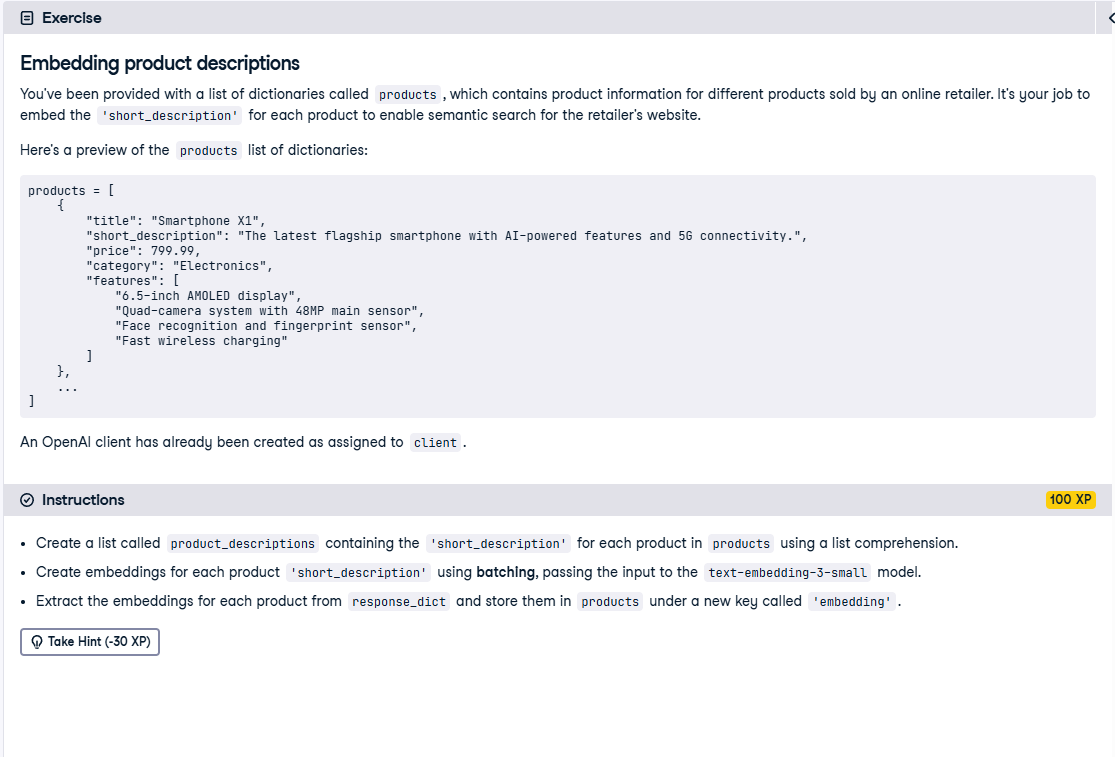

In [ ]:
# Extract a list of product short descriptions from products
product_descriptions = [product['short_description'] for product in products]

# Create embeddings for each product description
response = client.embeddings.create(model="text-embedding-3-small", input=product_descriptions)
response_dict = response.model_dump()

# Extract the embeddings from response_dict and store in products
for i, product in enumerate(products):
    product['embedding'] = response_dict['data'][i]['embedding']

print(products[0].items())

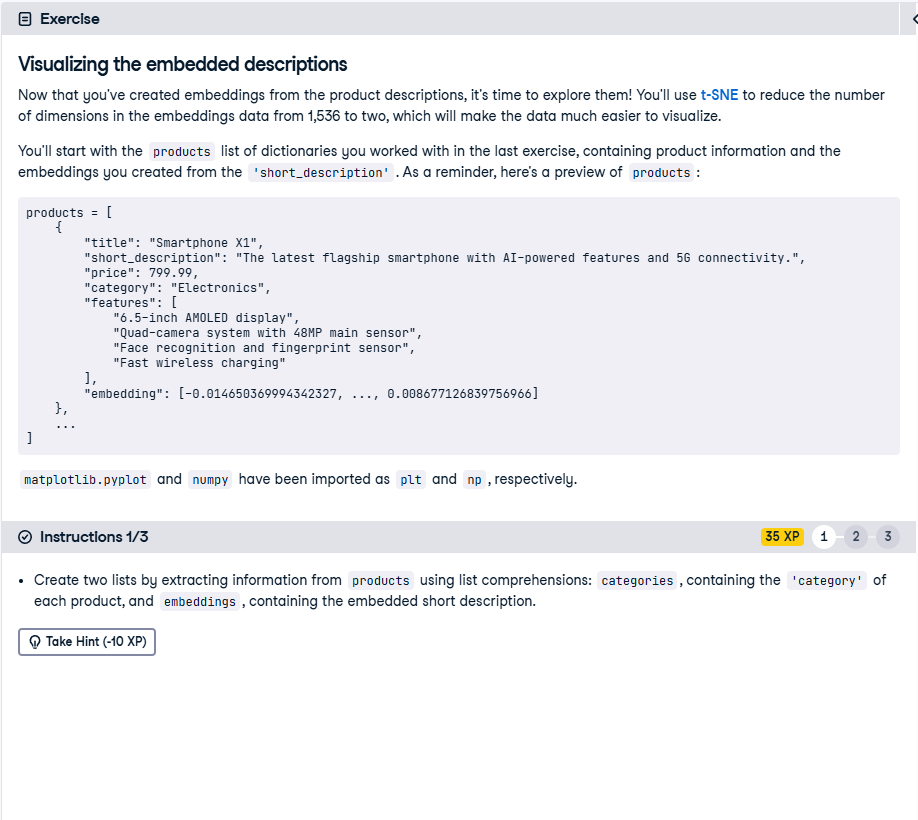

In [ ]:
# Create reviews and embeddings lists using list comprehensions
categories = [product['category'] for product in products]
embeddings = [product['embedding'] for product in products]

# Reduce the number of embeddings dimensions to two using t-SNE
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

# Create a scatter plot from embeddings_2d
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, category in enumerate(categories):
    plt.annotate(category, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.show()

# **Text similarity**
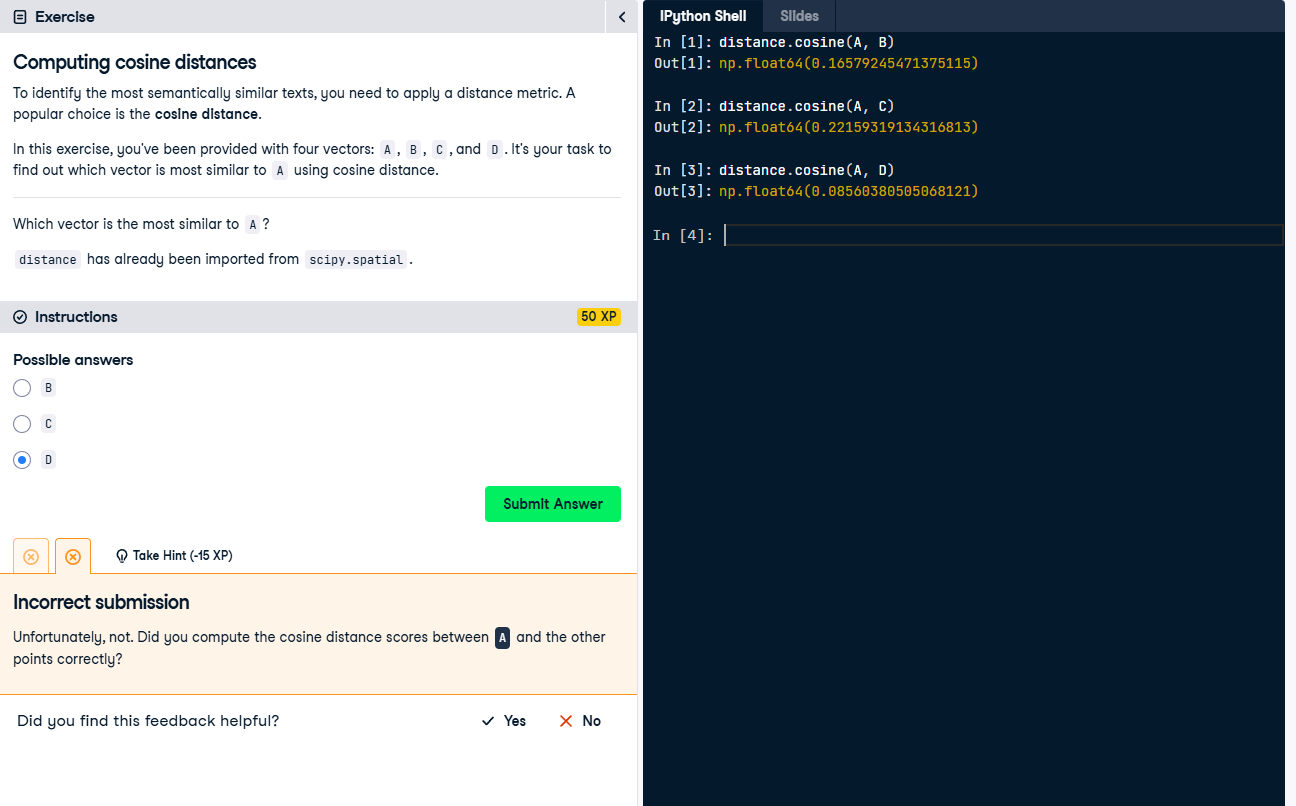

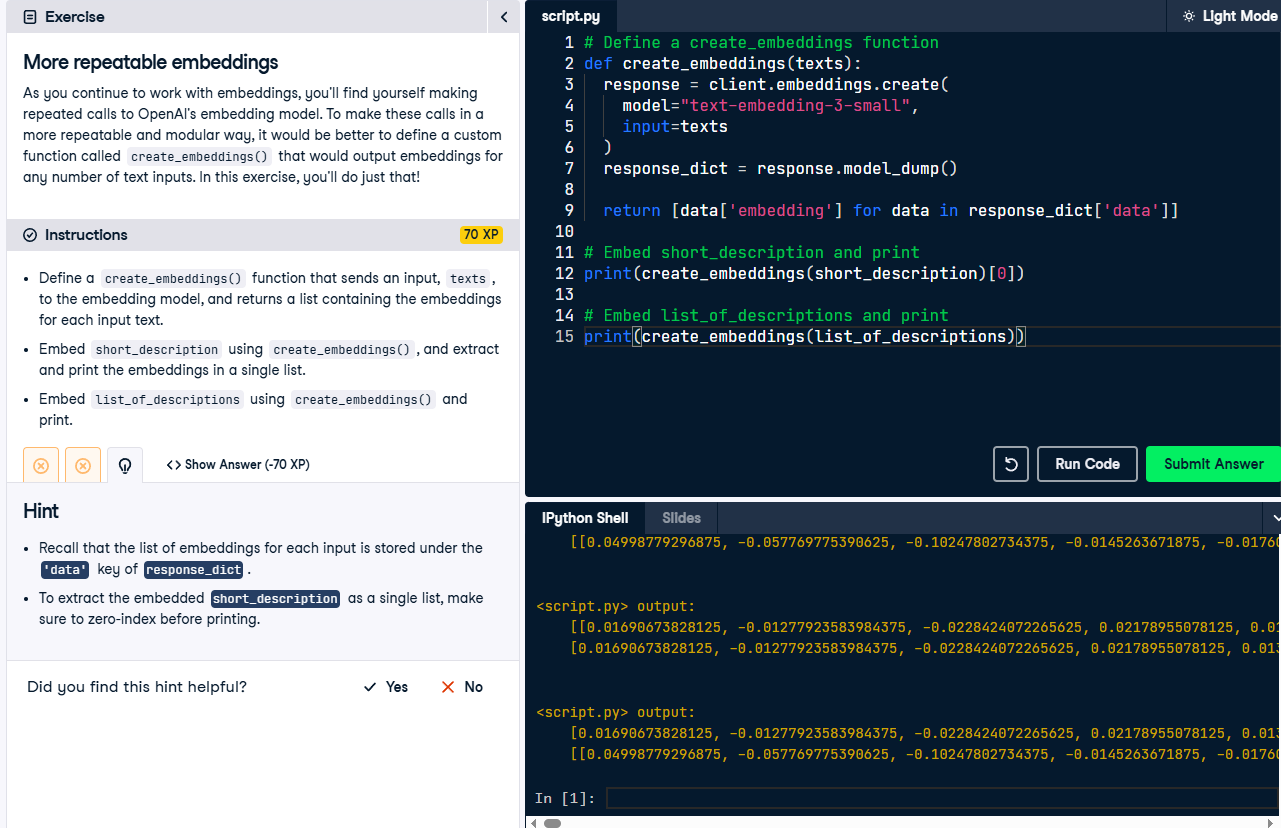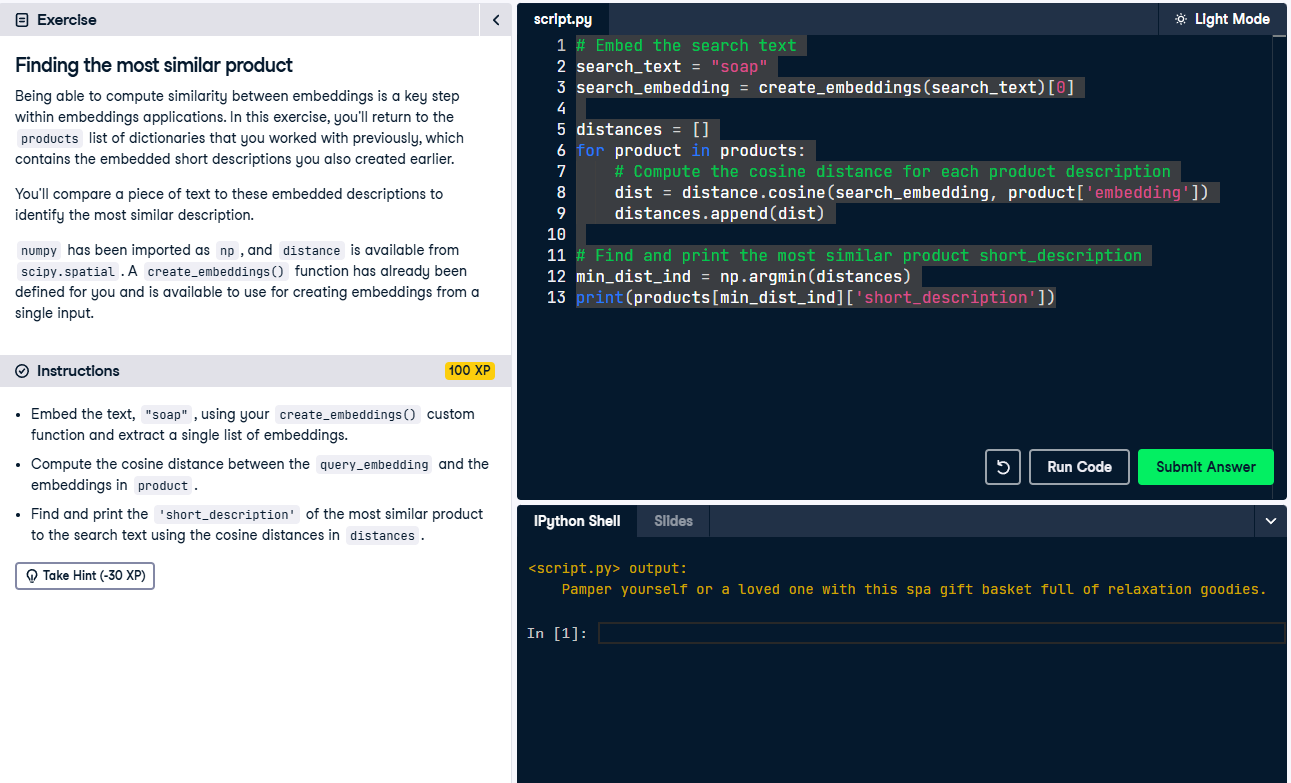

In [ ]:
# Define a create_embeddings function
def create_embeddings(texts):
  response = client.embeddings.create(
    model="text-embedding-3-small",
    input=texts
  )
  response_dict = response.model_dump()

  return [data['embedding'] for data in response_dict['data']]

# Embed short_description and print
print(create_embeddings(short_description)[0])

# Embed list_of_descriptions and print
print(create_embeddings(list_of_descriptions))

In [ ]:
# Embed the search text
search_text = "soap"
search_embedding = create_embeddings(search_text)[0]

distances = []
for product in products:
    # Compute the cosine distance for each product description
    dist = distance.cosine(search_embedding, product['embedding'])
    distances.append(dist)

# Find and print the most similar product short_description
min_dist_ind = np.argmin(distances)
print(products[min_dist_ind]['short_description'])

# Semantic search and enriched embeddings


In [ ]:
## Enriching embeddings

# Define a function to combine the relevant features into a single string
def create_product_text(product):
    return f"""Title: {product['title']}
Description: {product['short_description']}
Category: {product['category']}
Features: {'; '.join(product['features'])}"""

# Combine the features for each product
product_texts = [create_product_text(product) for product in products]

# Create the embeddings from product_texts
# Note: The exact function name here depends on the library your course environment is using.
# It is typically `embed`, `get_embeddings`, or `model.encode`.
product_embeddings = create_embeddings(product_texts)


## Sorting by similarity

def find_n_closest(query_vector, embeddings, n=3):
    distances = []
    for index, embedding in enumerate(embeddings):
        # Calculate the cosine distance between the query vector and embedding
        dist = distance.cosine(query_vector, embedding)
        # Append the distance and index to distances
        distances.append({"distance": dist, "index": index})
    # Sort distances by the distance key
    distances_sorted = sorted(distances, key=lambda x: x["distance"])
    # Return the first n elements in distances_sorted
    return distances_sorted[:n]

# Recommendation systems using embeddings

Works very similiar to semantic search!

1. Embed the potential recommendations and data point
2. Calculate cosine distances
3. Recommend closest items

In [ ]:
### Product recommendation system

# Combine the features for last_product and each product in products
last_product_text = create_product_text(last_product)
product_texts = [create_product_text(product) for product in products]

# Embed last_product_text and product_texts
last_product_embeddings = create_embeddings(last_product_text)[0]
product_embeddings = create_embeddings(product_texts)

# Find the three smallest cosine distances and their indexes
hits = find_n_closest(last_product_embeddings, product_embeddings)

for hit in hits:
  product = products[hit['index']]
  print(product['title'])


### Adding user history to the recommendation engine
# Prepare and embed the user_history, and calculate the mean embeddings
history_texts = [create_product_text(article) for article in user_history]
history_embeddings = create_embeddings(history_texts)
mean_history_embeddings = np.mean(history_embeddings, axis=0)

# Filter products to remove any in user_history
products_filtered = [product for product in products if product not in user_history]

# Combine product features and embed the resulting texts
product_texts = [create_product_text(product) for product in products_filtered]
product_embeddings = create_embeddings(product_texts)

hits = find_n_closest(mean_history_embeddings, product_embeddings)

for hit in hits:
    product = products_filtered[hit['index']]
    print(product['title'])

# Embeddings for classification tasks

- Assigning labels to items
  - Categorization
  - Sentiment analysis

- Zero-shot classification
  - Not using labeled data


Process:
1. Embed class description
2. Embed the item to classify
3. Compute cosine distances
4. Assign the most similiar label

Limitations:
- Class descriptions sometimes lack sufficient details

In [ ]:
### Embedding restaurant reviews

# Create a list of class descriptions from the sentiment labels
class_descriptions = [sentiment['label'] for sentiment in sentiments]

# Embed the class_descriptions and reviews
class_embeddings = create_embeddings(class_descriptions)
review_embeddings = create_embeddings(reviews)

####################################################################################

### Classifying review sentiment

# Define a function to return the minimum distance and its index
def find_closest(query_vector, embeddings):
    distances = []
    for index, embedding in enumerate(embeddings):
        dist = distance.cosine(query_vector, embedding)
        distances.append({"distance": dist, "index": index})
    return min(distances, key=lambda x: x["distance"])

for index, review in enumerate(reviews):
    # Find the closest distance and its index using find_closest()
    closest = find_closest(review_embeddings[index], class_embeddings)
    # Subset sentiments using the index from closest
    label = sentiments[closest["index"]]["label"]
    print(f'"{review}" was classified as {label}')

##################################################################################

### Embedding more detailed descriptions
# Extract and embed the descriptions from sentiments
class_descriptions = [sentiment['description'] for sentiment in sentiments]
class_embeddings = create_embeddings(class_descriptions)
review_embeddings = create_embeddings(reviews)

def find_closest(query_vector, embeddings):
    distances = []
    for index, embedding in enumerate(embeddings):
        dist = distance.cosine(query_vector, embedding)
        distances.append({"distance": dist, "index": index})
    return min(distances, key=lambda x: x["distance"])

for index, review in enumerate(reviews):
    closest = find_closest(review_embeddings[index], class_embeddings)
    label = sentiments[closest['index']]['label']
    print(f'"{review}" was classified as {label}')



# Vector databases for embedding systems

Embedded documents are stored and queried from the vector database

**Components to store**
- Embeddings
- Source texts
- Metadata
- IDs and references
- Additional data useful for filtering results

Top tip: Don't store the source text as
metadata!

In [ ]:
### Creating vector databases with ChromaDB

# Create a persistant client
client = chromadb.PersistentClient()

# Create a netflix_title collection using the OpenAI Embedding function
collection = client.create_collection(
    name="netflix_titles",
    embedding_function=OpenAIEmbeddingFunction(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

# List the collections
print(client.list_collections())


### Estimating embedding costs with tiktoken

# Load the encoder for the OpenAI text-embedding-3-small model
enc = tiktoken.encoding_for_model("text-embedding-3-small")

# Encode each text in documents and calculate the total tokens
total_tokens = sum(len(enc.encode(doc)) for doc in documents)

cost_per_1k_tokens = 0.00002

# Display number of tokens and cost
print('Total tokens:', total_tokens)
print('Cost:', (total_tokens / 1000) * cost_per_1k_tokens)




### Adding data to the collection

# Recreate the netflix_titles collection
collection = client.create_collection(
    name="netflix_titles",
    embedding_function=OpenAIEmbeddingFunction(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

# Add the documents and IDs to the collection
collection.add(documents=documents, ids=ids)

# Print the collection size and first ten items
print(f"No. of documents: {collection.count()}")
print(f"First ten documents: {collection.peek()}")

# Querying and updating the database



In [ ]:
### Querying the Netflix collection

# Retrieve the netflix_titles collection
collection = client.get_collection(
  name="netflix_titles",
  embedding_function=OpenAIEmbeddingFunction(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

# Query the collection for "films about dogs"
result = collection.query(
    query_texts=["films about dogs"],
    n_results=3
)

print(result)


### Updating and deleting items from a collection

collection = client.get_collection(
  name="netflix_titles",
  embedding_function=OpenAIEmbeddingFunction(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

# Update or add the new documents
collection.upsert(
    ids=[item["id"] for item in new_data],
    documents=[item["document"] for item in new_data]
)

# Delete the item with ID "s95"
collection.delete(ids=["s95"])

result = collection.query(
    query_texts=["films about dogs"],
    n_results=3
)
print(result)

# Multiple queries and filtering




In [ ]:
### Querying with multiple texts

collection = client.get_collection(
    name="netflix_titles",
    embedding_function=OpenAIEmbeddingFunction
(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

reference_ids = ['s999', 's1000']

# Retrieve the documents for the reference_ids
reference_texts = collection.get(ids=reference_ids)['documents']

# Query using reference_texts
result = collection.query(
    query_texts=reference_texts,
    n_results=3
)

print(result['documents'])


### Filtering using metadata

collection = client.get_collection(
    name="netflix_titles",
    embedding_function=OpenAIEmbeddingFunction
(model_name="text-embedding-3-small", api_key="<OPENAI_API_TOKEN>")
)

reference_texts = ["children's story about a car", "lions"]

# Query two results using reference_texts
result = collection.query(
    query_texts=reference_texts,
    n_results=2,
    # Filter for titles with a G rating released before 2019
    where={
        "$and": [
            {"rating":
                {"$eq": "G"}
            },
            {"release_year":
                {"$lt": 2019}
            }
        ]
    }
)

print(result['documents'])
